In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/raksha-farmer-query.csv')
display(df.head())

,StateName,DistrictName,BlockName,Season,Sector,Category,Crop,QueryType,QueryText,CreatedOn,year,month
0,KARNATAKA,HUBBALLI,PUSAD,NaN,HORTICULTURE,Others,Others,Market,Farmer asked about sowing time of Onion?,2025-03-20T06:45:00,2025,3
1,MAHARASHTRA,AKOLA,SAKOLI,NaN,HORTICULTURE,Others,Others,Market,FARMER ASKED ABOUT FERTILIZER DOSES FOR CITRUS...,2025-03-08T02:35:00,2025,3
2,MAHARASHTRA,LATUR,PUSAD,NaN,AGRICULTURE,Others,Others,Market,FARMER ASKED ABOUT CONTROL OF BLIGHT ATTACK ON...,2025-02-03T08:13:00,2025,2
3,UTTAR PRADESH,LUCKNOW,SAKOLI,NaN,HORTICULTURE,Others,Others,Market,FARMER ASKED ABOUT FARMER ID CARD PROBLEM?,2025-03-10T02:44:00,2025,3
4,MAHARASHTRA,LATUR,PAUNI,NaN,AGRICULTURE,Others,Others,Market,Farmer asked about irrigation schedule for Onion?,2025-02-02T11:51:00,2025,2


In [3]:
# Assuming the 'Category' column holds the query categories
category_counts = df['Category'].value_counts()
display(category_counts)

,count
Category,
Others,2000


/tmp/ipykernel_2640/198284735.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')


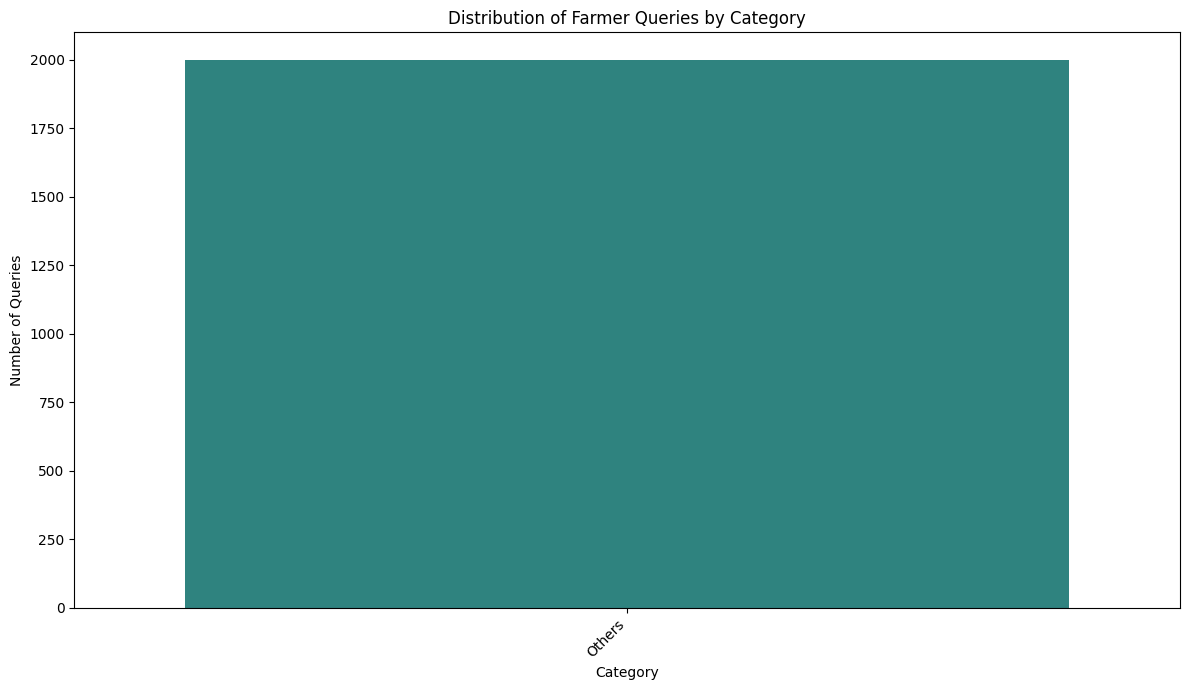

In [4]:
plt.figure(figsize=(12, 7))
sns.barplot(x=category_counts.index, y=category_counts.values, palette='viridis')
plt.title('Distribution of Farmer Queries by Category')
plt.xlabel('Category')
plt.ylabel('Number of Queries')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The 'Category' column shows all queries as 'Others', so it's not useful for detailed analysis. Let's examine the 'QueryType' column instead, as it might offer more specific insights into farmer concerns.

In [5]:
# Analyze the distribution of 'QueryType'
query_type_counts = df['QueryType'].value_counts()
display(query_type_counts)

,count
QueryType,
Market,357
Plant Protection,348
Weather,334
Government Schemes,334
Nutrient Management,323
Seeds,304


/tmp/ipykernel_2640/3383143400.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=query_type_counts.index, y=query_type_counts.values, palette='coolwarm')


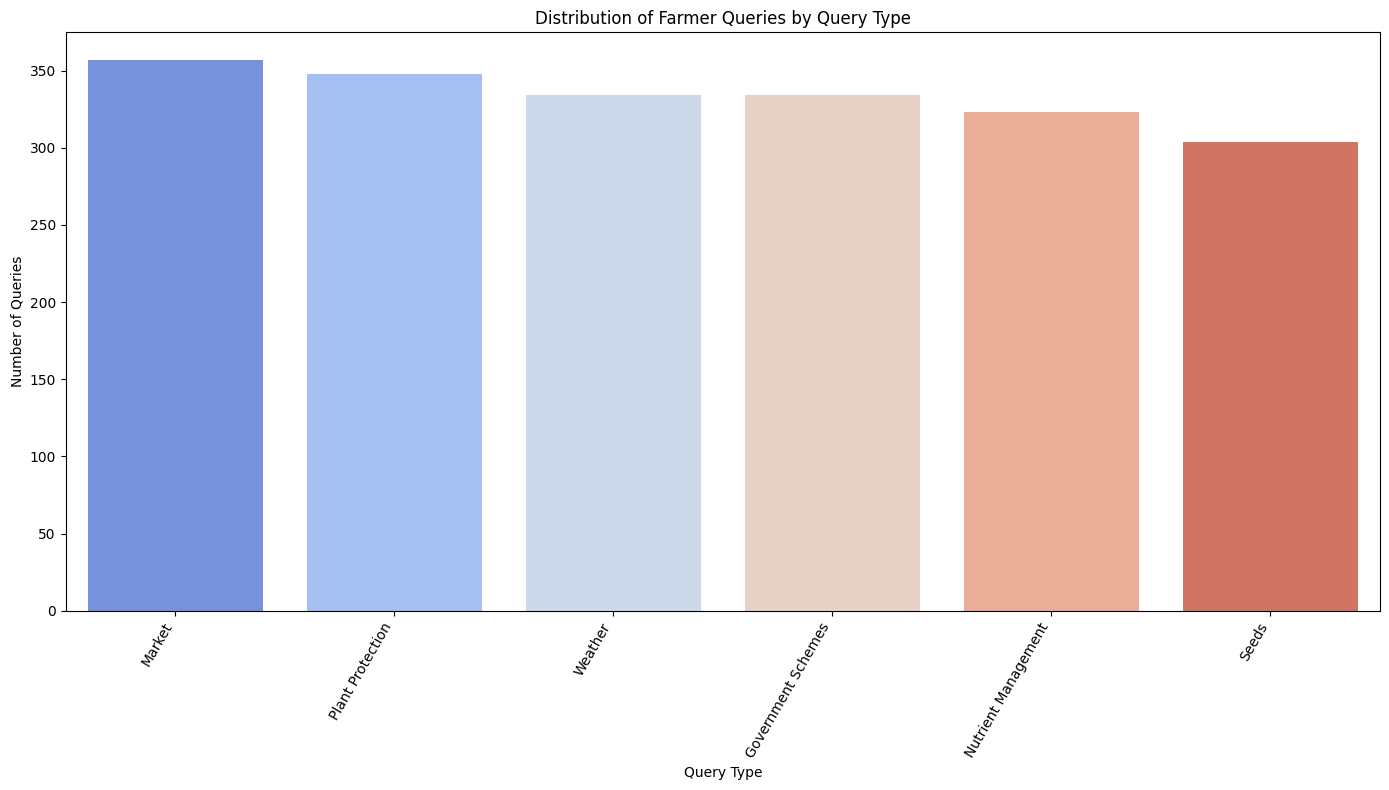

In [6]:
plt.figure(figsize=(14, 8))
sns.barplot(x=query_type_counts.index, y=query_type_counts.values, palette='coolwarm')
plt.title('Distribution of Farmer Queries by Query Type')
plt.xlabel('Query Type')
plt.ylabel('Number of Queries')
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

Let's analyze seasonal trends using the 'CreatedOn' column. We will extract month and year and then visualize the query distribution.

In [7]:
# Convert 'CreatedOn' to datetime if not already done
# Check if 'CreatedOn' column exists in df
if 'CreatedOn' in df.columns:
    df['CreatedOn'] = pd.to_datetime(df['CreatedOn'])
    # Extract month and year
    df['query_month'] = df['CreatedOn'].dt.month
    df['query_year'] = df['CreatedOn'].dt.year
    display(df[['CreatedOn', 'query_month', 'query_year']].head())
else:
    print("Error: 'CreatedOn' column not found in DataFrame.")

,CreatedOn,query_month,query_year
0,2025-03-20 06:45:00,3,2025
1,2025-03-08 02:35:00,3,2025
2,2025-02-03 08:13:00,2,2025
3,2025-03-10 02:44:00,3,2025
4,2025-02-02 11:51:00,2,2025


/tmp/ipykernel_2640/1324939406.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_queries.index, y=monthly_queries.values, palette='viridis')


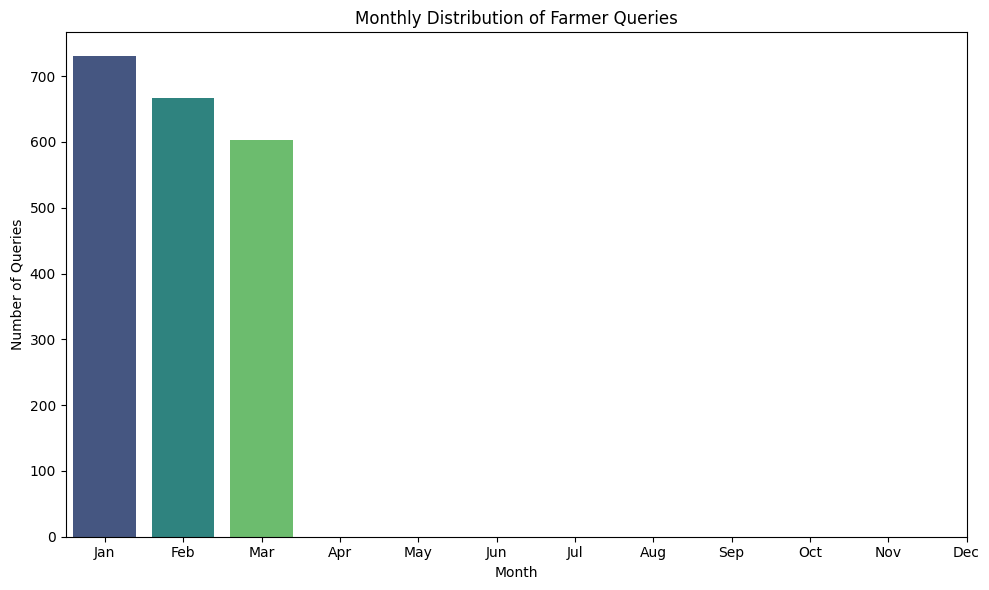

In [8]:
# Analyze query distribution by month
monthly_queries = df['query_month'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=monthly_queries.index, y=monthly_queries.values, palette='viridis')
plt.title('Monthly Distribution of Farmer Queries')
plt.xlabel('Month')
plt.ylabel('Number of Queries')
plt.xticks(ticks=range(0, 12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

/tmp/ipykernel_2640/1408985440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_queries.index.astype(str), y=yearly_queries.values, palette='plasma')


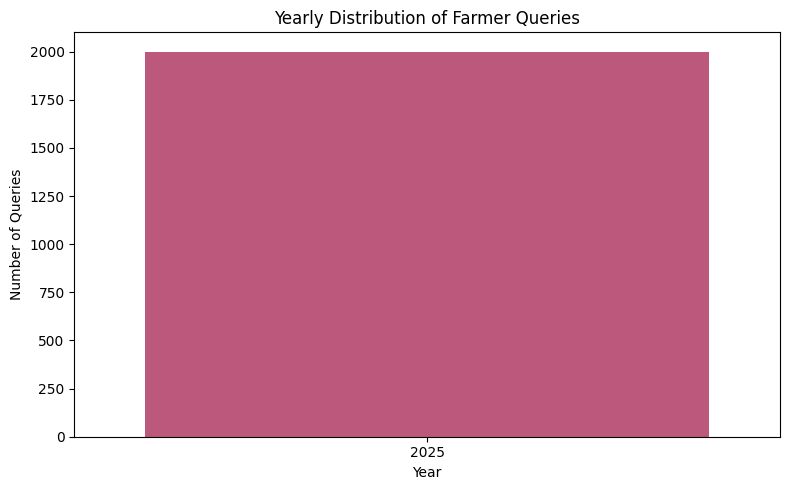

In [9]:
# Analyze query distribution by year
yearly_queries = df['query_year'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=yearly_queries.index.astype(str), y=yearly_queries.values, palette='plasma')
plt.title('Yearly Distribution of Farmer Queries')
plt.xlabel('Year')
plt.ylabel('Number of Queries')
plt.tight_layout()
plt.show()

Let's also look at the monthly trends for the top QueryTypes to see if specific concerns are seasonal.

<Figure size 1400x800 with 0 Axes>

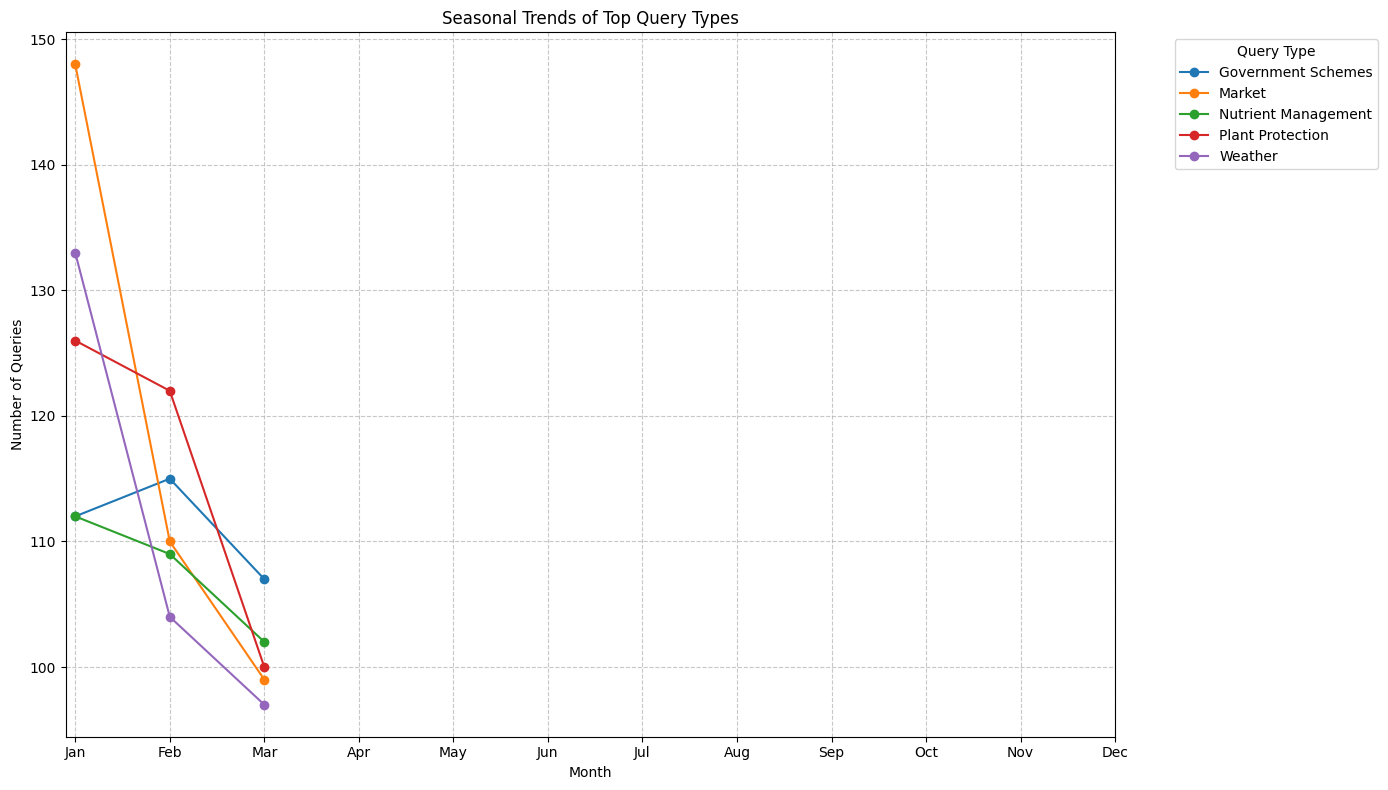

In [10]:
# Get top N QueryTypes for focused analysis (e.g., top 5)
top_query_types = df['QueryType'].value_counts().nlargest(5).index

# Filter DataFrame to include only top query types
df_top_query_types = df[df['QueryType'].isin(top_query_types)]

# Group by month and QueryType and count queries
seasonal_query_type_trends = df_top_query_types.groupby(['query_month', 'QueryType']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
seasonal_query_type_trends.plot(kind='line', marker='o', figsize=(14, 8))
plt.title('Seasonal Trends of Top Query Types')
plt.xlabel('Month')
plt.ylabel('Number of Queries')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Query Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()